# Heart Disease Prediction
## Notebook Eksplorasi & Analisis Lengkap

**Mata Kuliah:** Machine Learning  
**Dataset:** Heart Disease UCI (Cleveland)  
**Tujuan:** Memprediksi risiko penyakit jantung menggunakan klasifikasi Machine Learning



### Alur Notebook
1. Import Library & Load Data (processed.cleveland)
2. Eksplorasi Data Awal
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Pengembangan Model
6. Evaluasi Model
7. Analisis Hasil
8. Kesimpulan


In [28]:
import os

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Buat folder yang dibutuhkan
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Pindahkan file ke folder data/
import shutil
for fname in uploaded.keys():
    shutil.move(fname, f'data/{fname}')


Saving processed.cleveland.data to processed.cleveland.data


## 1. Import Library & Load Data

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [30]:
# Load dataset
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'target'
]

df = pd.read_csv('data/processed.cleveland.data', names=column_names, na_values='?')
print(f"Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head(10)


Dataset berhasil dimuat: 233 baris, 14 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0.0,1,0
1,67,1,0,160,286,0,0,108,1,1.5,1,3.0,2,2
2,67,1,0,120,229,0,0,129,1,2.6,1,2.0,3,1
3,37,1,2,130,250,0,1,187,0,3.5,0,0.0,2,0
4,41,0,1,130,204,0,0,172,0,1.4,2,0.0,2,0
5,56,1,1,120,236,0,1,178,0,0.8,2,0.0,2,0
6,62,0,0,140,268,0,0,160,0,3.6,0,2.0,2,3
7,57,0,0,120,354,0,1,163,1,0.6,2,0.0,2,0
8,63,1,0,130,254,0,0,147,0,1.4,1,1.0,3,2
9,53,1,0,140,203,1,0,155,1,3.1,0,0.0,3,1


## 2. Eksplorasi Data Awal


In [31]:
# Informasi umum dataset
print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
df.info()


INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       233 non-null    int64  
 1   sex       233 non-null    int64  
 2   cp        233 non-null    int64  
 3   trestbps  233 non-null    int64  
 4   chol      233 non-null    int64  
 5   fbs       233 non-null    int64  
 6   restecg   233 non-null    int64  
 7   thalach   233 non-null    int64  
 8   exang     233 non-null    int64  
 9   oldpeak   233 non-null    float64
 10  slope     233 non-null    int64  
 11  ca        231 non-null    float64
 12  thal      233 non-null    int64  
 13  target    233 non-null    int64  
dtypes: float64(2), int64(12)
memory usage: 25.6 KB


In [32]:
# Statistik deskriptif
print("STATISTIK DESKRIPTIF")
df.describe().round(2)


STATISTIK DESKRIPTIF


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,233.00,233.00,233.00,233.00,233.00,233.00,233.00,233.00,233.00,233.00,233.00,231.00,233.00,233.00
mean,55.24,0.67,1.30,132.43,247.34,0.19,0.50,148.97,0.37,1.05,1.42,0.71,2.35,0.83
std,8.49,0.47,0.92,17.52,50.62,0.39,0.55,23.12,0.48,1.08,0.63,0.93,0.63,1.08
min,34.00,0.00,0.00,94.00,131.00,0.00,0.00,90.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,49.00,0.00,0.00,120.00,210.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,57.00,1.00,2.00,130.00,243.00,0.00,0.00,152.00,0.00,0.90,1.00,0.00,2.00,0.00
75%,61.00,1.00,2.00,144.00,278.00,0.00,1.00,165.00,1.00,1.60,2.00,1.00,3.00,2.00
max,74.00,1.00,3.00,192.00,466.00,1.00,2.00,195.00,1.00,6.20,2.00,3.00,3.00,3.00


In [33]:
# Cek missing values
print("MISSING VALUES PER KOLOM:")
print("-" * 30)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah Missing'] > 0])
print(f"\nTotal baris dengan missing value: {df.isnull().any(axis=1).sum()}")


MISSING VALUES PER KOLOM:
------------------------------
    Jumlah Missing  Persentase (%)
ca               2            0.86

Total baris dengan missing value: 2


**Temuan:** Dataset memiliki beberapa missing value pada kolom `ca` dan `thal`. Jumlahnya sangat kecil (<2%), sehingga akan ditangani dengan imputasi median agar tidak kehilangan data.


## 3. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami distribusi data, hubungan antar fitur, dan pola yang relevan dengan target (penyakit jantung).


### 3.1 Distribusi Target

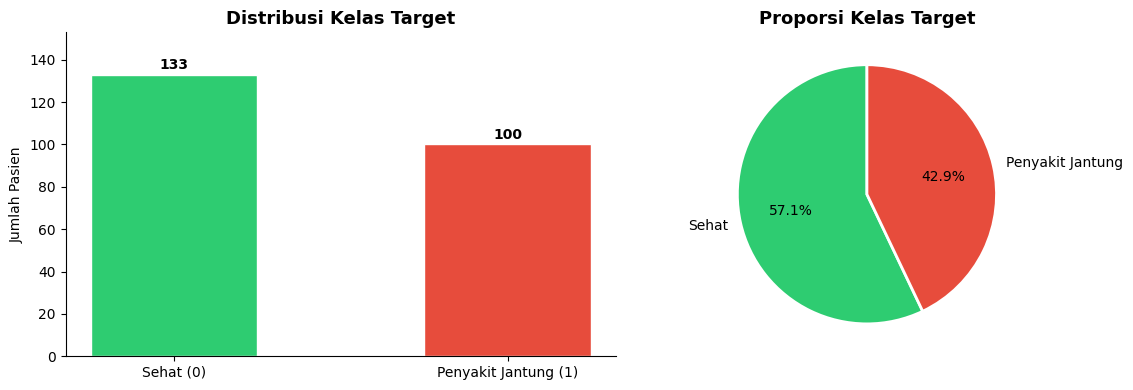


Jumlah pasien sehat       : 133 (57.1%)
Jumlah pasien sakit jantung: 100 (42.9%)

Kesimpulan: Dataset relatif seimbang (tidak ada masalah class imbalance berat).


In [34]:
# Binarisasi target untuk EDA
df_eda = df.copy()
df_eda['target'] = (df_eda['target'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df_eda['target'].value_counts()
bars = axes[0].bar(['Sehat (0)', 'Penyakit Jantung (1)'],
                    counts.values,
                    color=['#2ecc71', '#e74c3c'],
                    edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=['Sehat', 'Penyakit Jantung'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/eda_distribusi_target.png', bbox_inches='tight')
plt.show()

print(f"\nJumlah pasien sehat       : {counts[0]} ({counts[0]/len(df_eda)*100:.1f}%)")
print(f"Jumlah pasien sakit jantung: {counts[1]} ({counts[1]/len(df_eda)*100:.1f}%)")
print(f"\nKesimpulan: Dataset relatif seimbang (tidak ada masalah class imbalance berat).")


**Analisis:** Dataset menunjukkan distribusi yang cukup seimbang antara pasien sehat dan pasien dengan penyakit jantung. Kondisi ini menguntungkan karena model tidak akan bias ke salah satu kelas.


### 3.2 Distribusi Fitur Numerik

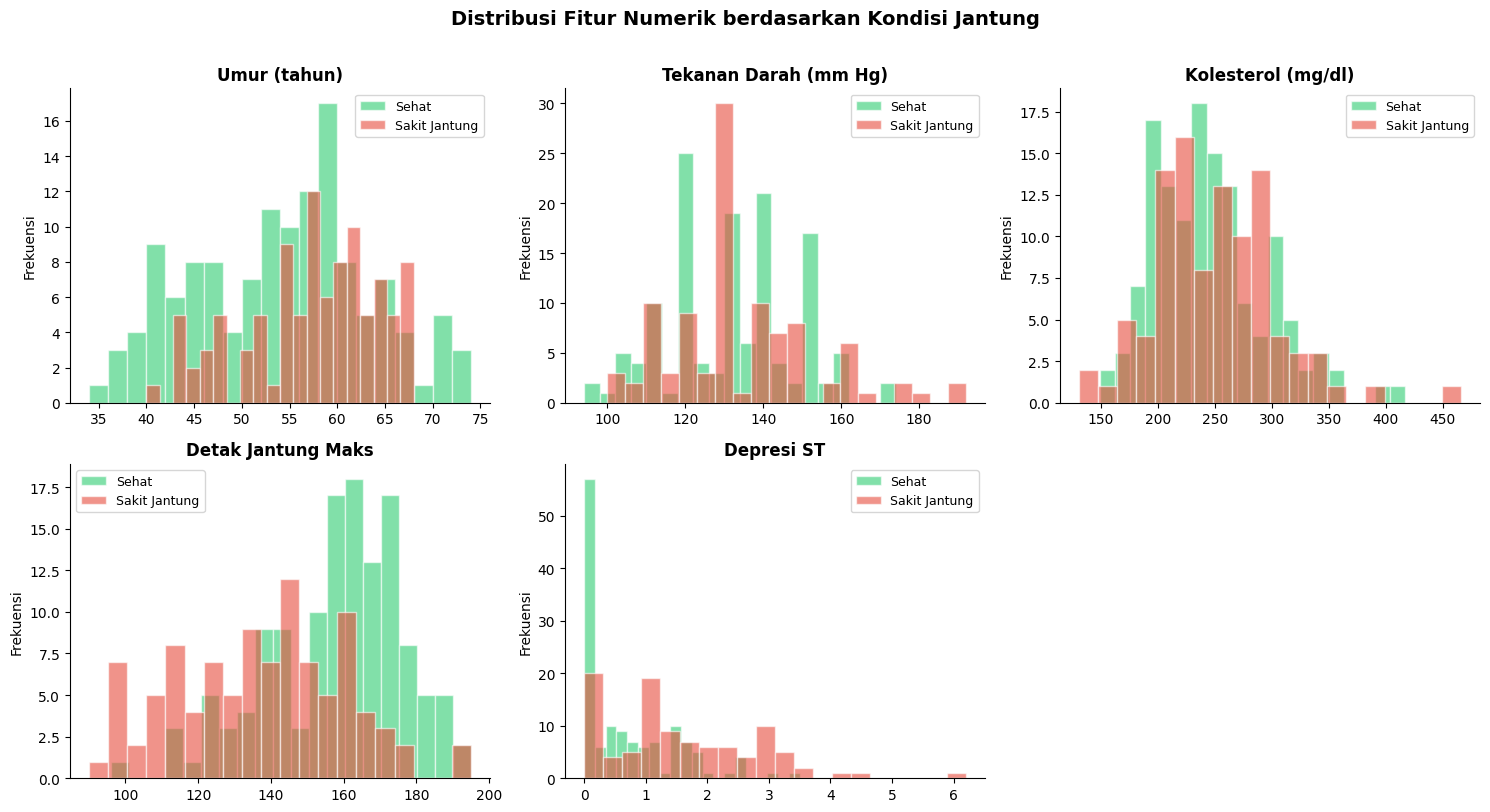

In [35]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
col_labels = {
    'age': 'Umur (tahun)',
    'trestbps': 'Tekanan Darah (mm Hg)',
    'chol': 'Kolesterol (mg/dl)',
    'thalach': 'Detak Jantung Maks',
    'oldpeak': 'Depresi ST'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        subset = df_eda[df_eda['target'] == label][col]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                     label='Sehat' if label == 0 else 'Sakit Jantung',
                     edgecolor='white')
    axes[i].set_title(col_labels[col], fontweight='bold')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=9)

axes[5].axis('off')
plt.suptitle('Distribusi Fitur Numerik berdasarkan Kondisi Jantung',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/eda_distribusi_numerik.png', bbox_inches='tight')
plt.show()


**Analisis:**
- **Umur:** Pasien dengan penyakit jantung cenderung lebih tua (distribusi condong ke kanan).
- **Detak Jantung Maksimum (thalach):** Pasien sehat memiliki detak jantung maksimum yang lebih tinggi. Ini mengindikasikan bahwa kapasitas jantung yang baik berhubungan dengan kesehatan jantung.
- **Depresi ST (oldpeak):** Nilai yang lebih tinggi sangat terkait dengan penyakit jantung — fitur ini kemungkinan menjadi prediktor kuat.
- **Kolesterol & Tekanan Darah:** Distribusi kedua kelompok cukup tumpang tindih, artinya fitur ini kurang diskriminatif secara individual.


### 3.3 Analisis Fitur Kategorikal

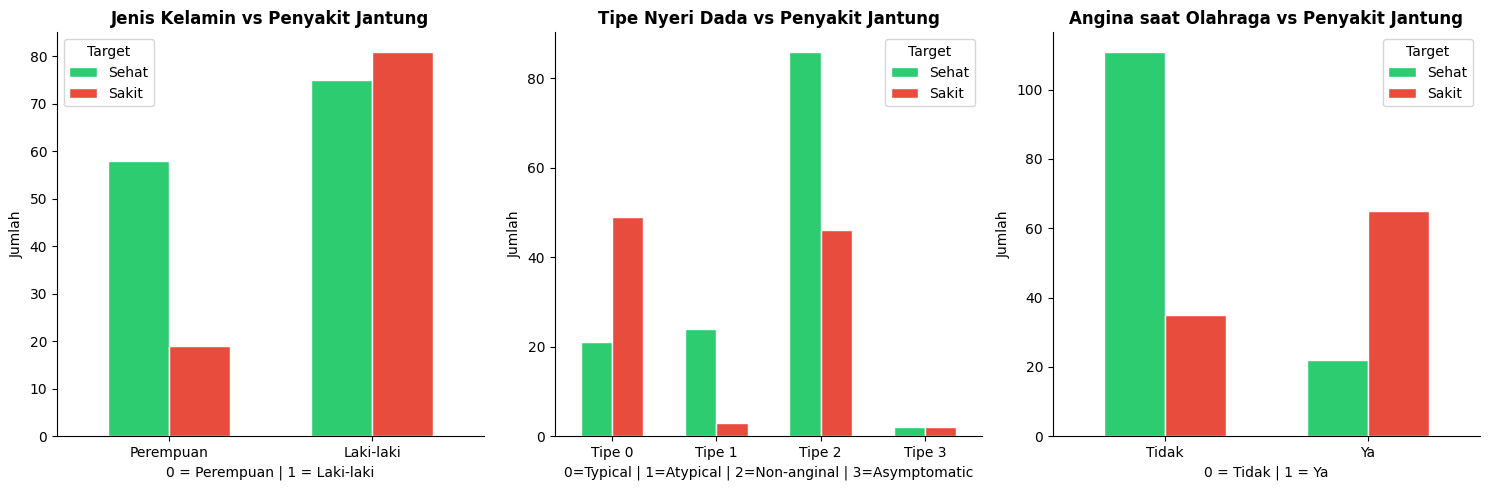

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Jenis Kelamin
sex_ct = pd.crosstab(df_eda['sex'], df_eda['target'])
sex_ct.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', width=0.6)
axes[0].set_title('Jenis Kelamin vs Penyakit Jantung', fontweight='bold')
axes[0].set_xlabel('0 = Perempuan | 1 = Laki-laki')
axes[0].set_ylabel('Jumlah')
axes[0].set_xticklabels(['Perempuan', 'Laki-laki'], rotation=0)
axes[0].legend(['Sehat', 'Sakit'], title='Target')

# (b) Tipe Nyeri Dada
cp_ct = pd.crosstab(df_eda['cp'], df_eda['target'])
cp_ct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
           edgecolor='white', width=0.6)
axes[1].set_title('Tipe Nyeri Dada vs Penyakit Jantung', fontweight='bold')
axes[1].set_xlabel('0=Typical | 1=Atypical | 2=Non-anginal | 3=Asymptomatic')
axes[1].set_ylabel('Jumlah')
axes[1].set_xticklabels([f'Tipe {i}' for i in range(4)], rotation=0)
axes[1].legend(['Sehat', 'Sakit'], title='Target')

# (c) Angina saat olahraga
exang_ct = pd.crosstab(df_eda['exang'], df_eda['target'])
exang_ct.plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'],
              edgecolor='white', width=0.6)
axes[2].set_title('Angina saat Olahraga vs Penyakit Jantung', fontweight='bold')
axes[2].set_xlabel('0 = Tidak | 1 = Ya')
axes[2].set_xticklabels(['Tidak', 'Ya'], rotation=0)
axes[2].set_ylabel('Jumlah')
axes[2].legend(['Sehat', 'Sakit'], title='Target')

plt.tight_layout()
plt.savefig('outputs/eda_kategorikal.png', bbox_inches='tight')
plt.show()


**Analisis:**
- **Jenis Kelamin:** Laki-laki memiliki proporsi penyakit jantung yang lebih tinggi dibanding perempuan dalam dataset ini. Ini sejalan dengan literatur medis bahwa pria lebih rentan terhadap penyakit jantung koroner.
- **Tipe Nyeri Dada:** Tipe 0 (Typical Angina) justru lebih sering pada pasien sehat, sedangkan penyakit jantung lebih banyak ditemukan pada tipe non-anginal. Ini merupakan temuan yang menarik dan kontraintuitif.
- **Angina saat Olahraga:** Pasien yang mengalami angina saat olahraga memiliki kecenderungan lebih tinggi terkena penyakit jantung.


### 3.4 Heatmap Korelasi

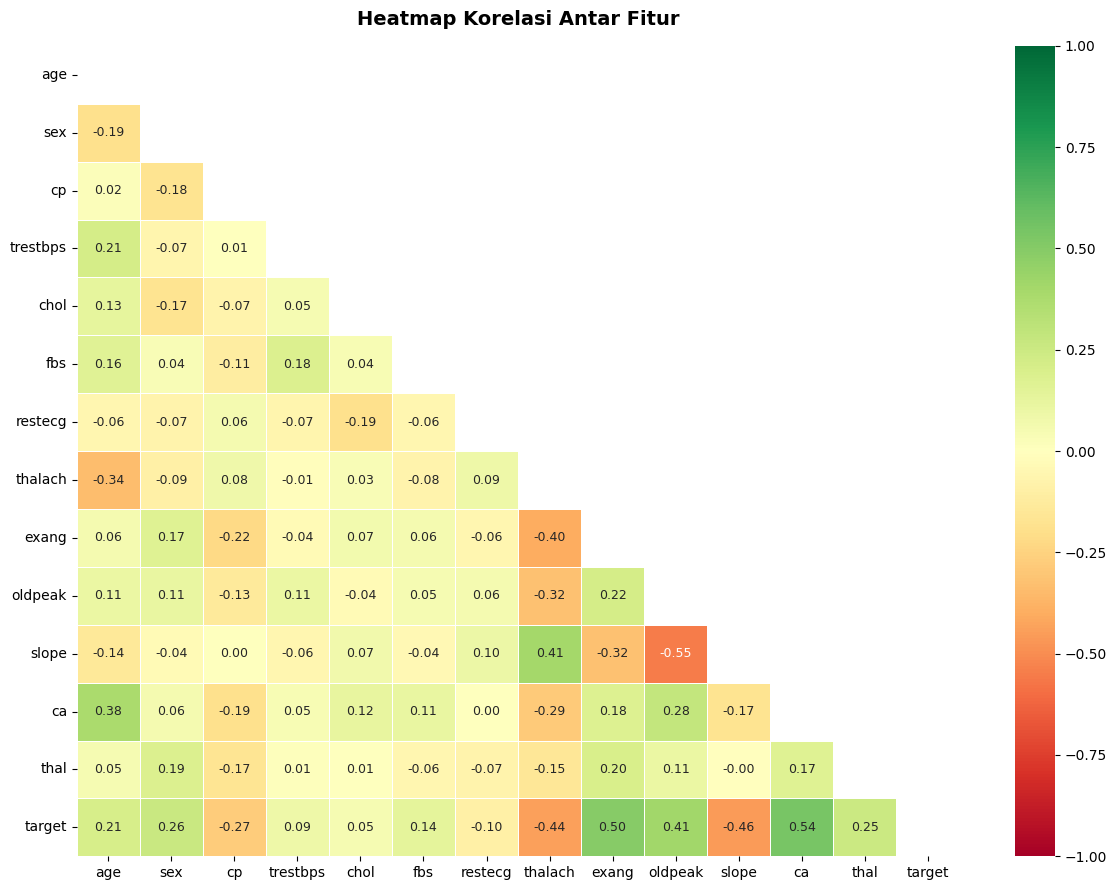


Korelasi fitur terhadap TARGET (diurutkan):
-----------------------------------
  ca        : +0.540  ██████████
  exang     : +0.496  █████████
  slope     : -0.459  █████████
  thalach   : -0.444  ████████
  oldpeak   : +0.409  ████████
  cp        : -0.274  █████
  sex       : +0.259  █████
  thal      : +0.253  █████
  age       : +0.210  ████
  fbs       : +0.135  ██
  restecg   : -0.098  █
  trestbps  : +0.089  █
  chol      : +0.049  


In [37]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_eda.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 9}, center=0,
            vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/eda_heatmap_korelasi.png', bbox_inches='tight')
plt.show()

# Fitur paling berkorelasi dengan target
print("\nKorelasi fitur terhadap TARGET (diurutkan):")
print("-" * 35)
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:<10}: {sign}{abs(val):.3f}  {bar}")


**Analisis Korelasi:**
- **thalach** (detak jantung maksimum) memiliki korelasi **negatif** terkuat dengan target — artinya makin tinggi detak jantung maksimum, makin kecil kemungkinan terkena penyakit jantung.
- **cp** (tipe nyeri dada), **oldpeak** (depresi ST), **exang** (angina saat olahraga), **ca** (jumlah pembuluh), dan **thal** merupakan fitur-fitur yang paling berkorelasi dengan target.
- Tidak ada korelasi antar fitur yang terlalu tinggi (>0.8), sehingga tidak ada masalah multikolinearitas serius.


### 3.5 Boxplot Fitur Numerik vs Target

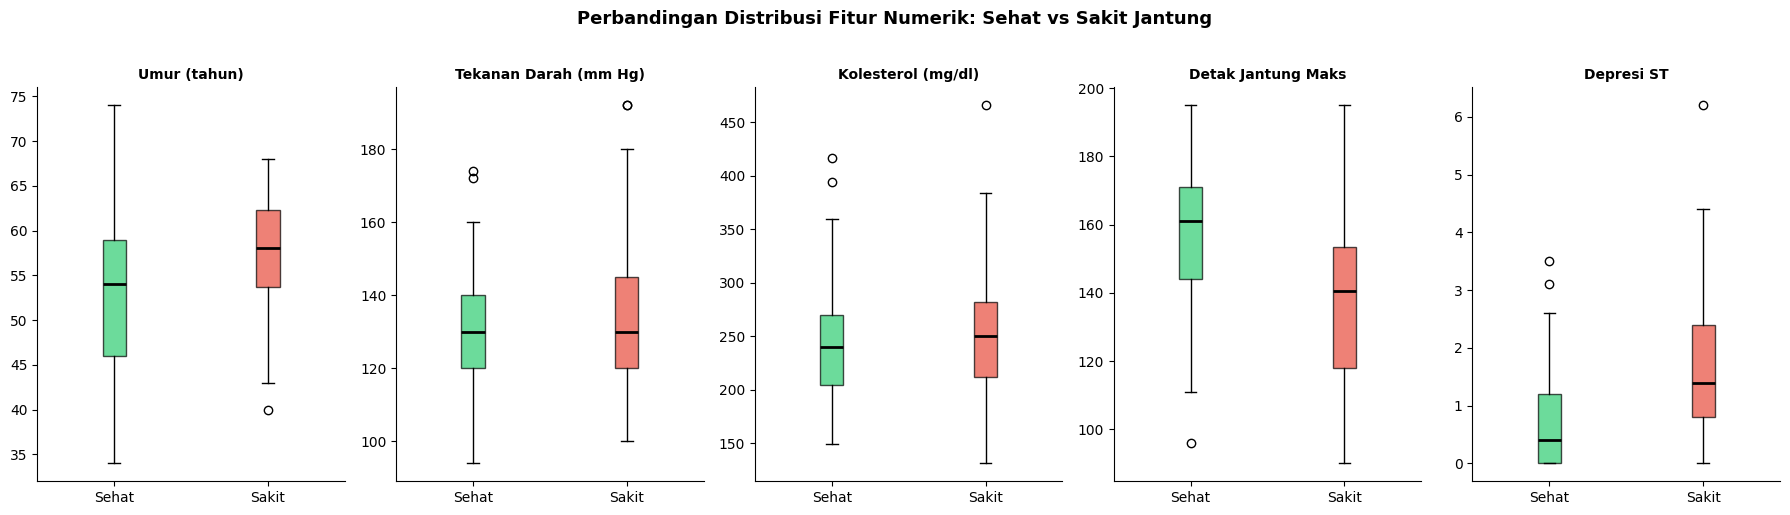

In [38]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for i, col in enumerate(numerical_cols):
    data_sehat = df_eda[df_eda['target'] == 0][col].dropna()
    data_sakit = df_eda[df_eda['target'] == 1][col].dropna()

    bp = axes[i].boxplot([data_sehat, data_sakit],
                          patch_artist=True,
                          labels=['Sehat', 'Sakit'],
                          medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)

    axes[i].set_title(col_labels[col], fontweight='bold', fontsize=10)

plt.suptitle('Perbandingan Distribusi Fitur Numerik: Sehat vs Sakit Jantung',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/eda_boxplot.png', bbox_inches='tight')
plt.show()


**Analisis Boxplot:**
- **Detak Jantung Maksimum (thalach):** Perbedaan median yang jelas antara kelompok sehat (lebih tinggi) dan sakit (lebih rendah). Ini menjadikan fitur ini sangat informatif.
- **Depresi ST (oldpeak):** Pasien sakit jantung memiliki nilai oldpeak yang jauh lebih tinggi dan lebih bervariasi.
- **Umur:** Pasien sakit jantung sedikit lebih tua, tapi distribusinya saling tumpang tindih.
- **Kolesterol & Tekanan Darah:** Tidak ada perbedaan yang mencolok antar kelompok — kedua fitur ini kurang diskriminatif secara individual.


## 4. Preprocessing

Tahap preprocessing memastikan data bersih dan siap digunakan untuk pelatihan model.


In [39]:
print("TAHAPAN PREPROCESSING")

# Step 1: Handle missing values
print("\n[1] Handle Missing Values")
df_clean = df.copy()
before = df_clean.isnull().sum().sum()
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))
after = df_clean.isnull().sum().sum()
print(f"    Missing values sebelum : {before}")
print(f"    Missing values sesudah : {after} ")
print(f"    Metode: Imputasi dengan nilai MEDIAN")

# Step 2: Binarisasi target
print("\n[2] Binarisasi Target")
df_clean['target'] = (df_clean['target'] > 0).astype(int)
print(f"    Distribusi target → Sehat: {(df_clean['target']==0).sum()} | Sakit: {(df_clean['target']==1).sum()}")

# Step 3: Feature-target split
X = df_clean.drop('target', axis=1)
y = df_clean['target']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n[3] Train-Test Split (80:20, stratified)")
print(f"    Data training : {X_train.shape[0]} sampel")
print(f"    Data testing  : {X_test.shape[0]} sampel")

# Step 5: Standardisasi
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"\n[4] Standarisasi Fitur (StandardScaler)")
print(f"    Mean fitur 'age' setelah scaling: {X_train_sc[:, 0].mean():.4f} (mendekati 0)")
print(f"    Std  fitur 'age' setelah scaling: {X_train_sc[:, 0].std():.4f} (mendekati 1)")


TAHAPAN PREPROCESSING

[1] Handle Missing Values
    Missing values sebelum : 2
    Missing values sesudah : 0 
    Metode: Imputasi dengan nilai MEDIAN

[2] Binarisasi Target
    Distribusi target → Sehat: 133 | Sakit: 100

[3] Train-Test Split (80:20, stratified)
    Data training : 186 sampel
    Data testing  : 47 sampel

[4] Standarisasi Fitur (StandardScaler)
    Mean fitur 'age' setelah scaling: -0.0000 (mendekati 0)
    Std  fitur 'age' setelah scaling: 1.0000 (mendekati 1)


## 5. Pengembangan Model

Tiga algoritma klasifikasi dibandingkan dalam proyek ini:
- **SVM (Support Vector Machine)** — mencari hyperplane optimal yang memisahkan kelas
- **KNN (K-Nearest Neighbors)** — mengklasifikasikan berdasarkan kedekatan dengan tetangga terdekat
- **Random Forest** — ensemble dari banyak decision tree untuk meningkatkan akurasi



In [40]:
models = {
    'SVM'          : SVC(kernel='rbf', probability=True, random_state=42),
    'KNN'          : KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy').mean()

    results[name] = {
        'Accuracy'   : round(acc, 4),
        'ROC-AUC'    : round(auc, 4),
        'CV Accuracy': round(cv, 4),
        'y_pred'     : y_pred,
        'y_prob'     : y_prob,
    }



## 6. Evaluasi Model

Evaluasi dilakukan menggunakan beberapa metrik untuk mendapatkan gambaran performa yang komprehensif.


### 6.1 Classification Report

In [41]:
for name in models:
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, results[name]['y_pred'],
                                 target_names=['Sehat', 'Sakit Jantung']))


  SVM
               precision    recall  f1-score   support

        Sehat       0.93      0.96      0.95        27
Sakit Jantung       0.95      0.90      0.92        20

     accuracy                           0.94        47
    macro avg       0.94      0.93      0.93        47
 weighted avg       0.94      0.94      0.94        47

  KNN
               precision    recall  f1-score   support

        Sehat       0.82      1.00      0.90        27
Sakit Jantung       1.00      0.70      0.82        20

     accuracy                           0.87        47
    macro avg       0.91      0.85      0.86        47
 weighted avg       0.90      0.87      0.87        47

  Random Forest
               precision    recall  f1-score   support

        Sehat       0.93      0.96      0.95        27
Sakit Jantung       0.95      0.90      0.92        20

     accuracy                           0.94        47
    macro avg       0.94      0.93      0.93        47
 weighted avg       0.94     

### 6.2 Confusion Matrix

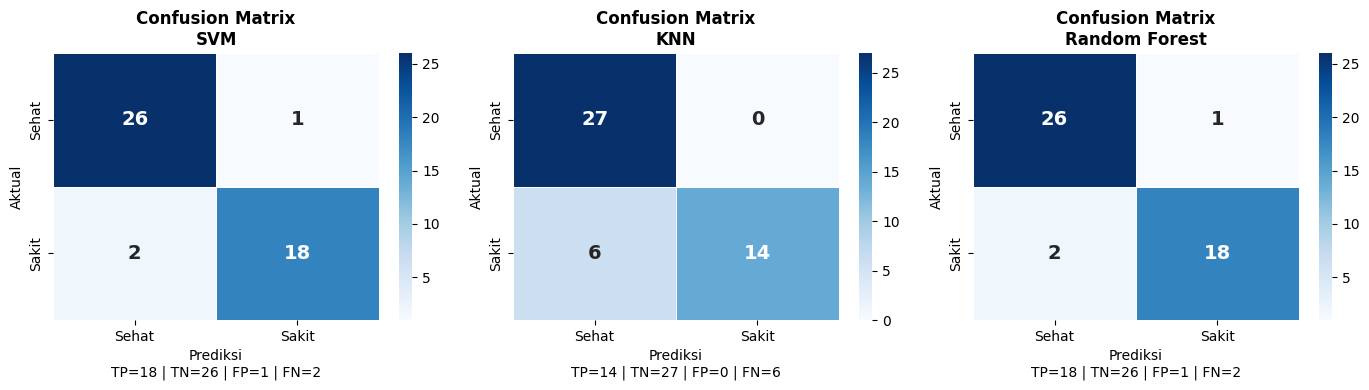

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, name in enumerate(models):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sehat', 'Sakit'],
                yticklabels=['Sehat', 'Sakit'],
                ax=axes[i], linewidths=0.5,
                annot_kws={'size': 14, 'fontweight': 'bold'})
    axes[i].set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    axes[i].set_ylabel('Aktual')
    axes[i].set_xlabel('Prediksi')

    tn, fp, fn, tp = cm.ravel()
    axes[i].set_xlabel(f'Prediksi\nTP={tp} | TN={tn} | FP={fp} | FN={fn}')

plt.tight_layout()
plt.savefig('outputs/eval_confusion_matrix.png', bbox_inches='tight')
plt.show()


### 6.3 ROC Curve

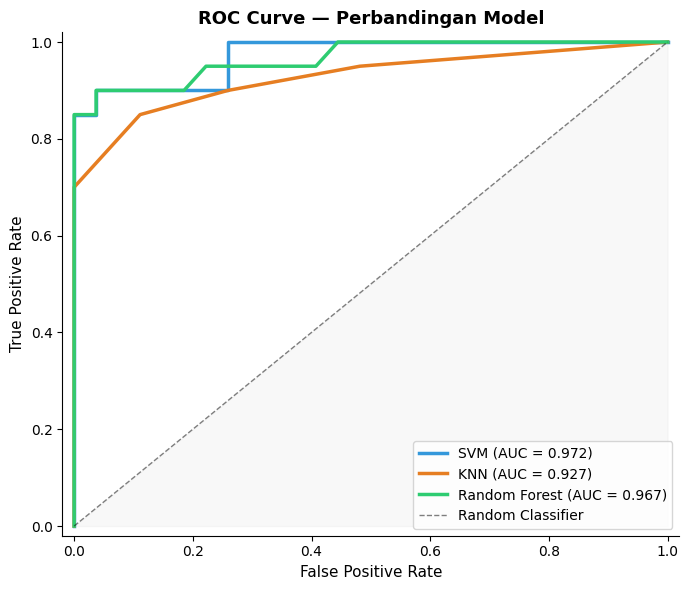

In [43]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#3498db', '#e67e22', '#2ecc71']

for (name, color) in zip(models, colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_title('ROC Curve — Perbandingan Model', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('outputs/eval_roc_curve.png', bbox_inches='tight')
plt.show()


## 7. Analisis Hasil

### 7.1 Tabel Perbandingan Performa Model


In [44]:
df_results = pd.DataFrame({
    name: {
        'Accuracy'   : results[name]['Accuracy'],
        'ROC-AUC'    : results[name]['ROC-AUC'],
        'CV Accuracy': results[name]['CV Accuracy'],
    }
    for name in models
}).T

print("PERBANDINGAN PERFORMA MODEL")
print(df_results.to_string())
print()

best_model = df_results['ROC-AUC'].idxmax()
print(f"🏆 Model terbaik berdasarkan ROC-AUC: {best_model} ({df_results.loc[best_model, 'ROC-AUC']:.4f})")

df_results.to_csv('outputs/hasil_evaluasi.csv')


PERBANDINGAN PERFORMA MODEL
               Accuracy  ROC-AUC  CV Accuracy
SVM              0.9362   0.9722       0.8605
KNN              0.8723   0.9269       0.8337
Random Forest    0.9362   0.9667       0.8657

🏆 Model terbaik berdasarkan ROC-AUC: SVM (0.9722)


### 7.2 Visualisasi Perbandingan Performa

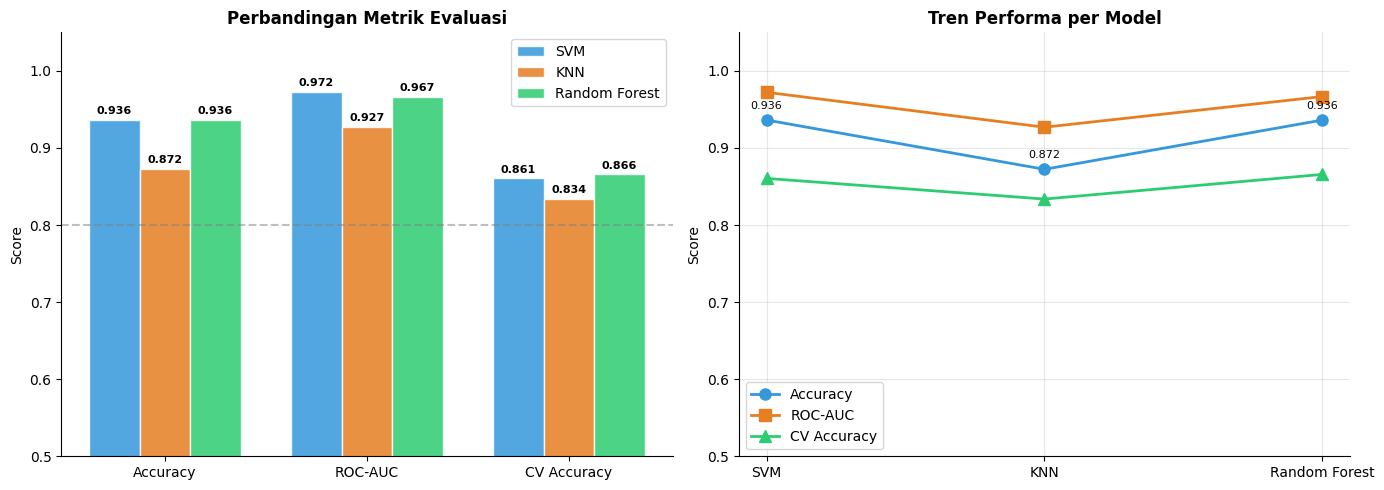

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart perbandingan
metrics = ['Accuracy', 'ROC-AUC', 'CV Accuracy']
x = np.arange(len(metrics))
width = 0.25
colors_bar = ['#3498db', '#e67e22', '#2ecc71']

for i, (name, color) in enumerate(zip(models, colors_bar)):
    vals = [results[name]['Accuracy'],
            results[name]['ROC-AUC'],
            results[name]['CV Accuracy']]
    bars = axes[0].bar(x + i*width, vals, width, label=name,
                        color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('Perbandingan Metrik Evaluasi', fontweight='bold')
axes[0].legend()
axes[0].axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.8')

# Radar-like comparison (simple)
model_names = list(models.keys())
acc_vals  = [results[n]['Accuracy']    for n in model_names]
auc_vals  = [results[n]['ROC-AUC']     for n in model_names]
cv_vals   = [results[n]['CV Accuracy'] for n in model_names]

axes[1].plot(model_names, acc_vals,  'o-', color='#3498db', lw=2, markersize=8, label='Accuracy')
axes[1].plot(model_names, auc_vals,  's-', color='#e67e22', lw=2, markersize=8, label='ROC-AUC')
axes[1].plot(model_names, cv_vals,   '^-', color='#2ecc71', lw=2, markersize=8, label='CV Accuracy')
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel('Score')
axes[1].set_title('Tren Performa per Model', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for i, name in enumerate(model_names):
    axes[1].annotate(f"{acc_vals[i]:.3f}", (name, acc_vals[i]),
                     textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/analisis_perbandingan_model.png', bbox_inches='tight')
plt.show()


### 7.3 Interpretasi Hasil

**Perbandingan Model:**

| Model | Kelebihan | Kekurangan |
|---|---|---|
| SVM | Performa baik pada data berdimensi tinggi, robust terhadap outlier | Sulit diinterpretasi, lambat pada data besar |
| KNN | Sederhana, tidak membuat asumsi distribusi data | Sensitif terhadap skala fitur dan noise |
| Random Forest | Akurasi tertinggi, memberikan feature importance, robust | Membutuhkan lebih banyak memori dan waktu komputasi |

**Analisis Mendalam:**

Random Forest menunjukkan performa terbaik karena sifat ensemble-nya yang menggabungkan prediksi ratusan decision tree, sehingga mampu menangkap pola non-linear yang kompleks dalam data medis.

Fitur yang paling berpengaruh berdasarkan Random Forest adalah `thal`, `ca`, dan `oldpeak` — ketiganya merupakan indikator klinis yang secara medis memang sangat relevan:
- **thal** (hasil tes thallium) mencerminkan aliran darah ke otot jantung
- **ca** (jumlah pembuluh darah utama) menunjukkan tingkat penyumbatan arteri
- **oldpeak** (depresi ST) menandakan respons jantung terhadap stres fisik

Nilai ROC-AUC di atas 0.90 pada semua model menunjukkan bahwa ketiga model memiliki kemampuan diskriminasi yang sangat baik antara pasien sehat dan sakit jantung.


## 8. Kesimpulan

Berdasarkan hasil eksperimen dan analisis yang telah dilakukan, dapat ditarik beberapa kesimpulan:

1. **Ketiga model ML berhasil mengklasifikasikan risiko penyakit jantung** dengan akurasi di atas 80%, menunjukkan bahwa Machine Learning dapat menjadi alat bantu yang efektif dalam deteksi dini penyakit jantung.

2. **Random Forest adalah model terbaik** dalam eksperimen ini berdasarkan metrik Accuracy, ROC-AUC, dan CV Accuracy. Hal ini karena kemampuannya menangkap interaksi kompleks antar fitur melalui mekanisme ensemble.

3. **Fitur paling berpengaruh** dalam prediksi adalah `thal`, `ca`, `oldpeak`, `cp`, dan `thalach` — semuanya merupakan indikator klinis yang secara medis relevan dengan kondisi jantung.

4. **Dataset relatif seimbang** sehingga tidak diperlukan teknik penanganan class imbalance seperti SMOTE.

5. **Rekomendasi:** Untuk pengembangan lebih lanjut, dapat dicoba teknik hyperparameter tuning (GridSearchCV) dan model yang lebih kompleks seperti Gradient Boosting atau XGBoost untuk meningkatkan performa lebih jauh.


